In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/block_0.csv/block_0.csv')

In [ ]:
df_w=pd.read_csv('/content/drive/MyDrive/weather_hourly_darksky.csv')

In [ ]:
df['tstp'] =df['tstp'].astype('datetime64')

In [ ]:
df.dtypes

LCLid                     object
tstp              datetime64[ns]
energy(kWh/hh)            object
dtype: object

In [ ]:
df = df.rename(columns= {'energy(kWh/hh)':'energy'})

In [ ]:
i= df[df['energy'] =='Null'].index
df = df.drop(index = i)

In [ ]:
df['energy'] = df['energy'].astype('float')

In [ ]:
df_w.dtypes

visibility             float64
windBearing              int64
temperature            float64
time                    object
dewPoint               float64
pressure               float64
apparentTemperature    float64
windSpeed              float64
precipType              object
icon                    object
humidity               float64
summary                 object
dtype: object

In [ ]:
df_w['time'] = df_w['time'].astype('datetime64')

In [ ]:
energy_avg = df.groupby('tstp').mean()['energy'].reset_index()

<ipython-input-12-568723dd43a0>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  energy_avg = df.groupby('tstp').mean()['energy'].reset_index()


In [ ]:
#energy_avg= energy_avg[energy_avg['energy'] > 2]

In [ ]:
df1 = energy_avg.merge(df_w ,left_on ='tstp',right_on ='time',how ='inner')

In [ ]:
df1.head()

,tstp,energy,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,2011-12-03 09:00:00,0.149,13.07,262,11.00,2011-12-03 09:00:00,8.84,1002.07,11.00,5.99,rain,partly-cloudy-day,0.87,Partly Cloudy
1,2011-12-03 10:00:00,0.768,12.76,268,11.42,2011-12-03 10:00:00,7.52,1002.76,11.42,6.10,rain,partly-cloudy-day,0.77,Partly Cloudy
2,2011-12-03 11:00:00,0.588,13.07,274,11.41,2011-12-03 11:00:00,6.39,1003.24,11.41,6.20,rain,partly-cloudy-day,0.71,Partly Cloudy
3,2011-12-03 12:00:00,0.843,13.07,277,11.33,2011-12-03 12:00:00,5.42,1003.22,11.33,6.60,rain,partly-cloudy-day,0.67,Partly Cloudy
4,2011-12-03 13:00:00,0.120,13.07,277,11.41,2011-12-03 13:00:00,5.07,1003.29,11.41,7.05,rain,partly-cloudy-day,0.65,Partly Cloudy


In [ ]:
df1  =df1.drop_duplicates()
df1 =df1.dropna()

In [ ]:
df1.count()

tstp                   19611
energy                 19611
visibility             19611
windBearing            19611
temperature            19611
time                   19611
dewPoint               19611
pressure               19611
apparentTemperature    19611
windSpeed              19611
precipType             19611
icon                   19611
humidity               19611
summary                19611
dtype: int64

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

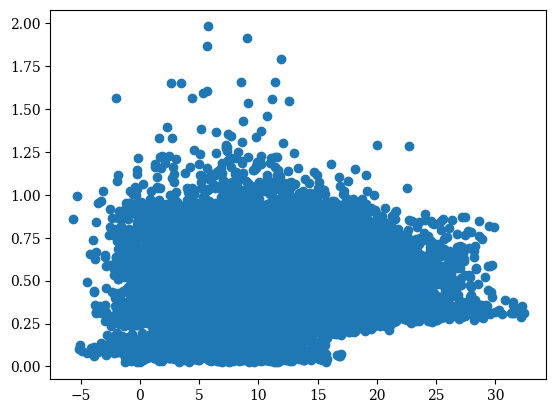

In [ ]:
plt.scatter(df1['temperature'] ,df1['energy'])

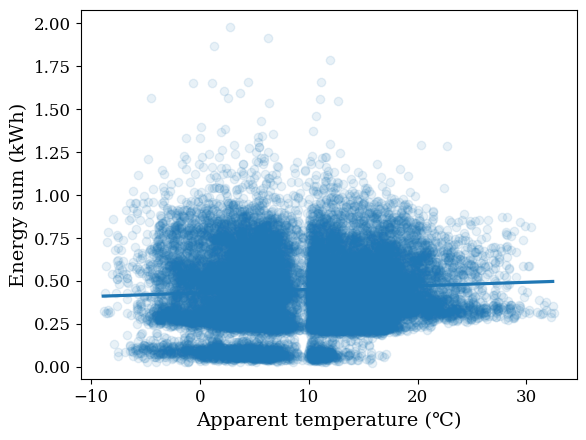

In [ ]:
sb.regplot(x= df1['apparentTemperature'] ,y = df1['energy'] ,scatter_kws = {'alpha' : 1/10} ,x_jitter = 0.2 ,fit_reg=True);
plt.xlabel("Apparent temperature (℃)" ,fontsize = 14)
plt.ylabel("Energy sum (kWh)" ,fontsize = 14 )
plt.xticks(fontsize = 12  )
plt.yticks(fontsize = 12)


from google.colab import files
plt.savefig("Tempretaure Vs sum energy for block 0.png",dpi=300, bbox_inches='tight')
#files.download("Tempretaure Vs sum energy for block 0.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 1200x1000 with 0 Axes>

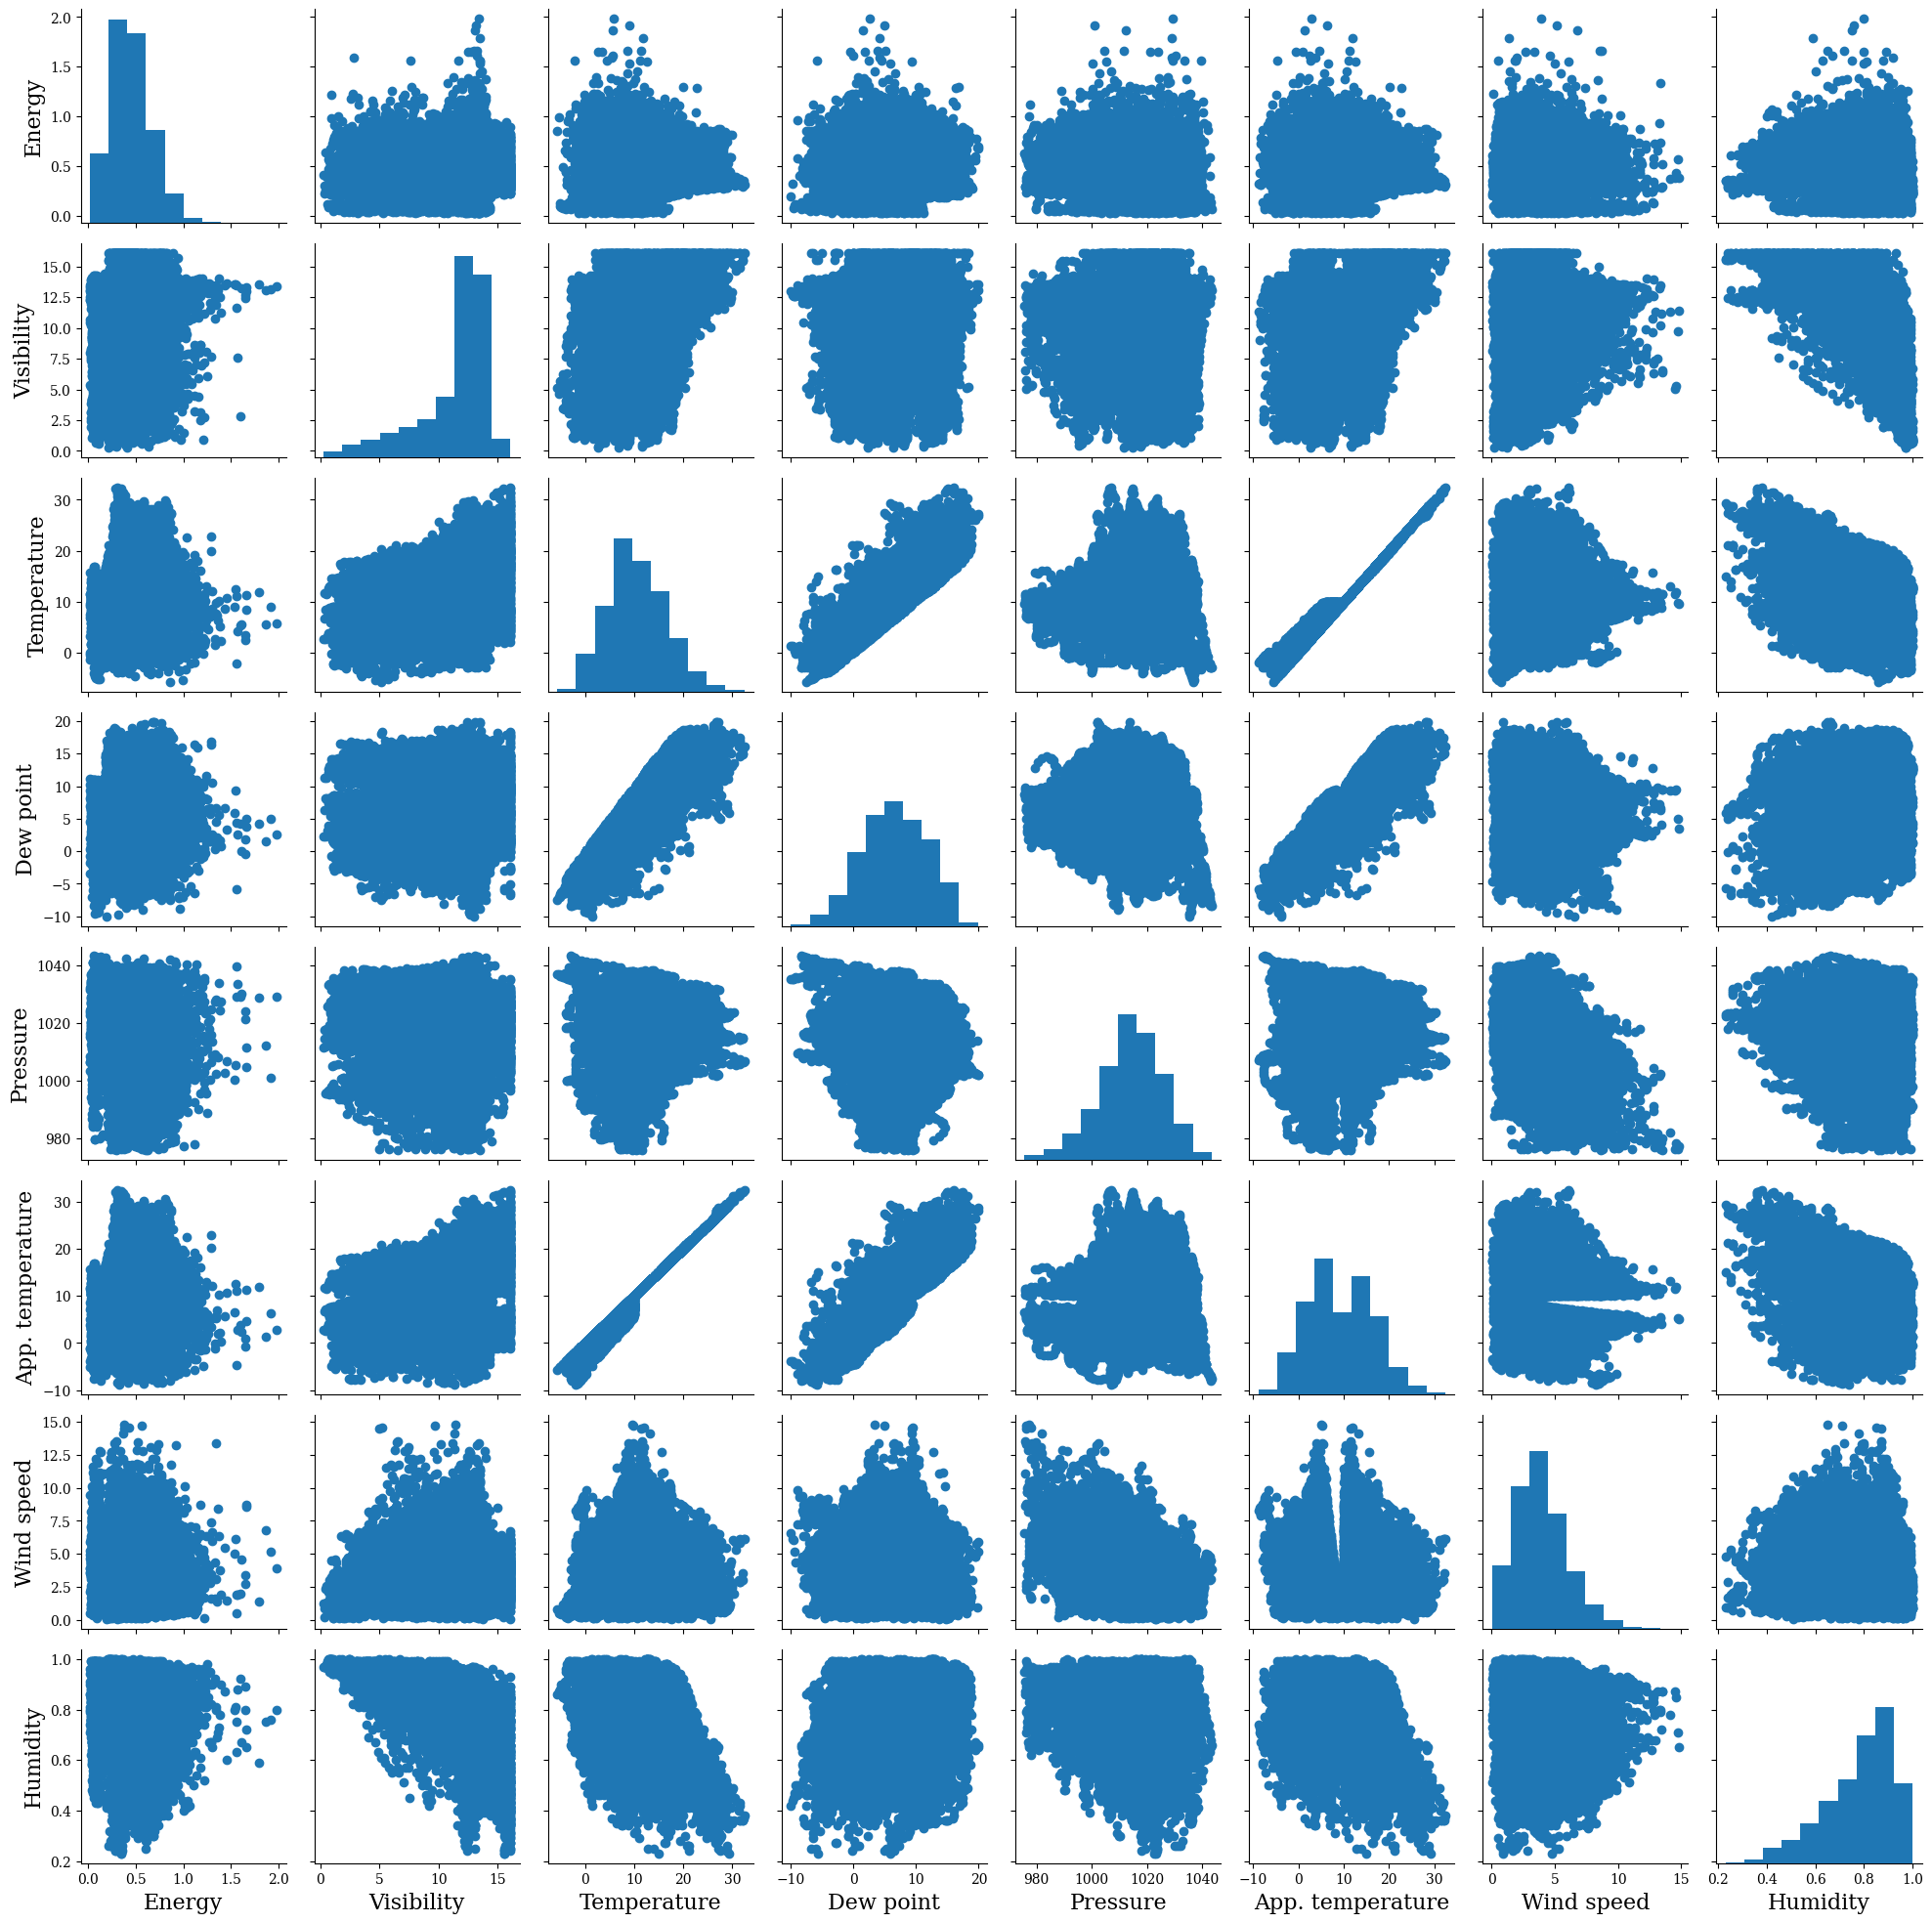

In [ ]:
plt.figure(figsize = [12,10])
vars =['energy','visibility','temperature','dewPoint','pressure','apparentTemperature','windSpeed','humidity']
g = sb.PairGrid(data =df1 , vars = vars)
g.map_offdiag(plt.scatter)
g.map_diag(plt.hist)
xlabels =['Energy' , 'Visibility' ,'Temperature' ,'Dew point' ,'Pressure' ,'App. temperature' , 'Wind speed' ,'Humidity']
ylabels = ['Energy' , 'Visibility' ,'Temperature' ,'Dew point' ,'Pressure' ,'App. temperature' , 'Wind speed' ,'Humidity']
for i in range(len(xlabels)):
  for j in range(len(ylabels)):
    g.axes[j,i].xaxis.set_label_text(label = xlabels[i],fontdict = {'size' :16})
    g.axes[j,i].yaxis.set_label_text(label = ylabels[j],fontdict = {'size' :16})
plt.savefig("complete analyis of all weather varaiables against energy for block 0.png",dpi=300, bbox_inches='tight')
files.download("complete analyis of all weather varaiables against energy for block 0.png")

## Rank Spearman Correlation for qualitative variables  

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/block_0.csv/block_0.csv')
df_w = pd.read_csv('/content/drive/MyDrive/weather_hourly_darksky.csv')

In [ ]:
df.dtypes

LCLid             object
tstp              object
energy(kWh/hh)    object
dtype: object

In [ ]:
df['tstp'] = df['tstp'].astype('datetime64')
df = df.rename(columns = {'energy(kWh/hh)':'energy'})
df = df[df['energy'] != 'Null']

In [ ]:
df['energy'] = df['energy'].astype('float')

In [ ]:
df_w['time'] = df_w['time'].astype('datetime64')

In [ ]:
energy_sum = df.groupby('tstp').sum()['energy'].reset_index()

<ipython-input-25-e90d1af145cb>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  energy_sum = df.groupby('tstp').sum()['energy'].reset_index()


In [ ]:
df1 = energy_sum.merge(df_w, how='inner' ,left_on = 'tstp',right_on='time')

In [ ]:
df1 = df1[df1['energy'] > 4]
df1.head(3)

NameError: ignored

In [ ]:
df1.groupby(['icon']).mean()['energy']

<ipython-input-28-4391b862503a>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df1.groupby(['icon']).mean()['energy']


icon
clear-day              14.903885
clear-night            15.712206
cloudy                 20.551433
fog                    18.678081
partly-cloudy-day      16.269193
partly-cloudy-night    20.880965
wind                   18.525208
Name: energy, dtype: float64

In [ ]:
icon_grouped = df1.groupby(['icon']).mean()['energy']

<ipython-input-29-d4f5108d8309>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  icon_grouped = df1.groupby(['icon']).mean()['energy']


In [ ]:
order = icon_grouped.sort_values().index

In [ ]:
icon_grouped

icon
clear-day              14.903885
clear-night            15.712206
cloudy                 20.551433
fog                    18.678081
partly-cloudy-day      16.269193
partly-cloudy-night    20.880965
wind                   18.525208
Name: energy, dtype: float64

In [ ]:
order

Index(['clear-day', 'clear-night', 'partly-cloudy-day', 'wind', 'fog',
       'cloudy', 'partly-cloudy-night'],
      dtype='object', name='icon')

In [ ]:
my_order_code = {'clear-day':1,'clear-night':2,'partly-cloudy-day':3,'wind':4,'fog':5,'cloudy':6,'partly-cloudy-night':7}

In [ ]:
df1['icon_coded']= df1['icon'].replace(my_order_code)

In [ ]:
df1['icon_coded']

2725     2
2916     7
2930     3
2940     7
2942     7
        ..
19617    7
19618    2
19619    2
19620    2
19621    2
Name: icon_coded, Length: 15500, dtype: int64

In [ ]:
df1 = df1.dropna()

In [ ]:
df1.columns

Index(['tstp', 'energy', 'visibility', 'windBearing', 'temperature', 'time',
       'dewPoint', 'pressure', 'apparentTemperature', 'windSpeed',
       'precipType', 'icon', 'humidity', 'summary', 'icon_coded'],
      dtype='object')

In [ ]:
from scipy.stats import spearmanr
coef,  p = spearmanr(df1['icon_coded'],df1['energy'])

In [ ]:
coef,p

(0.19844978891697415, 2.400294896446176e-137)

This meas that there is a weak correlation between icon and energy sum and the results are statistically significant (P_value < 0.05 )

[Text(1.5, 0, 'short'), Text(2.5, 0, 'medium'), Text(3.5, 0, 'long')]

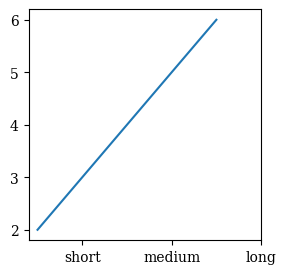

In [ ]:
x =[1,2,3]
y=[2,4,6]
plt.figure(figsize = [3,3])
plt.plot(x,y)
c,b = plt.xticks(ticks=[1.5 ,2.5 , 3.5],labels=['short','medium','long']);
b

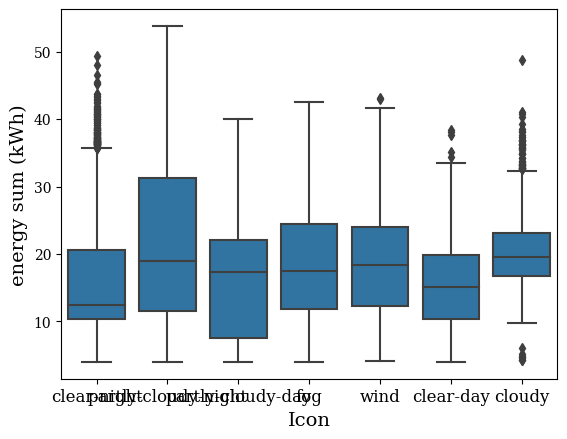

In [ ]:
base_color= sb.color_palette()[0]
xlabels = ['clear-day', 'clear-night', 'partly-cloudy-day', 'wind', 'fog','cloudy', 'partly-cloudy-night']
sb.boxplot(x='icon' , y='energy' ,data=df1 ,color =base_color);
#plt.xticks(rotation = 60);
plt.xlabel("Icon" ,fontsize = 14)
plt.ylabel("energy sum (kWh)" ,fontsize = 14 )

#plt.xticks(,labels= ['Clear\nday' ,'Clear\nnight' ,'Partly\ncloudy day','Wind','Fog','Cloudy','Partly\ncloudy night'],fontsize = 12  )
plt.xticks(fontsize = 12)

from google.colab import files
#plt.savefig("Icon Vs sum energy for block 0.png",dpi=300, bbox_inches='tight')
#files.download("Icon Vs sum energy for block 0.png")

## Repeat the same process for summary

In [ ]:
summary_grouped =df1.groupby(['summary']).mean()['energy']

<ipython-input-43-59a38088bb2a>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  summary_grouped =df1.groupby(['summary']).mean()['energy']


In [ ]:
order_summary = summary_grouped.sort_values().index

In [ ]:
order_summary

Index(['Clear', 'Partly Cloudy', 'Breezy and Partly Cloudy',
       'Breezy and Mostly Cloudy', 'Breezy', 'Foggy', 'Windy',
       'Windy and Mostly Cloudy', 'Mostly Cloudy', 'Overcast',
       'Breezy and Overcast', 'Windy and Overcast'],
      dtype='object', name='summary')

In [ ]:
summary_dict = {'Clear':1,'Partly Cloudy':2,'Breezy and Partly Cloudy':3,'Breezy and Mostly Cloudy':4,'Breezy':5,'Foggy':6,
                'Windy':7,'Windy and Mostly Cloudy':8,
                'Mostly Cloudy':9,'Overcast':10,'Breezy and Overcast':11,'Windy and Overcast':12}

In [ ]:
df1['summary_coded'] =df1['summary'].replace(summary_dict)

In [ ]:
from scipy.stats import spearmanr
coef_summary ,p_summary  = spearmanr(df1['summary_coded'],df1['energy'])
coef_summary ,p_summary

(0.21549538700480406, 3.549436448926091e-162)

There is a weak correlation between the summary and energy sum variables and results are statistically significant

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

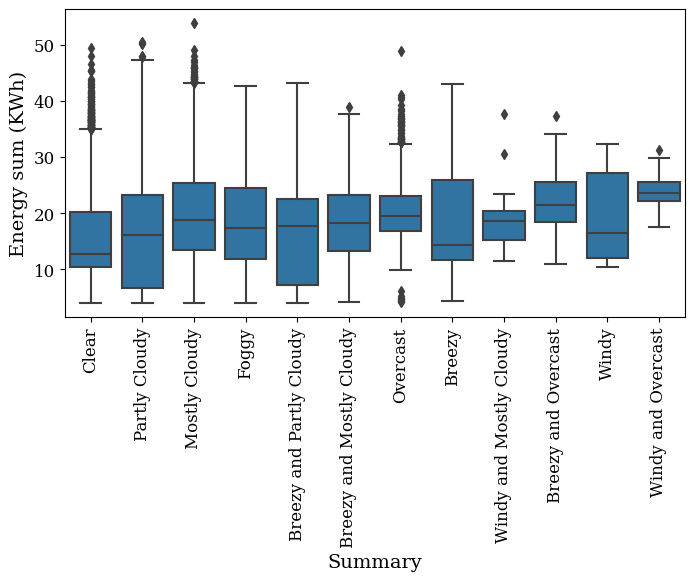

In [ ]:
base_color= sb.color_palette()[0]
plt.figure(figsize = [8,4])
sb.boxplot(x='summary' , y='energy' ,data=df1 ,color =base_color);
plt.xticks(rotation = 90);
plt.xlabel("Summary" ,fontsize = 14)
plt.ylabel("Energy sum (KWh)" ,fontsize = 14 )
plt.xticks(fontsize = 12  )
plt.yticks(fontsize = 12)

from google.colab import files
plt.savefig("Summary vs energy sum for block 0.png", dpi =300 , bbox_inches='tight')
files.download("Summary vs energy sum for block 0.png")

In [ ]:
precip = df1.groupby(['precipType']).mean()['energy']

<ipython-input-50-b48a380b9b15>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  precip = df1.groupby(['precipType']).mean()['energy']


In [ ]:
precip_index = precip.sort_values().index

In [ ]:
precip_index

Index(['rain', 'snow'], dtype='object', name='precipType')

In [ ]:
precip_dict = {'rain':1,'snow':2}

In [ ]:
df1['precip_coded'] = df1['precipType'].replace(precip_dict)

In [ ]:
from scipy.stats import spearmanr
coef_summary ,p_summary  = spearmanr(df1['precip_coded'],df1['energy'])
coef_summary ,p_summary

(0.09011981682451518, 2.648028252920258e-29)

So weak correlation and results are statisticallly significant

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

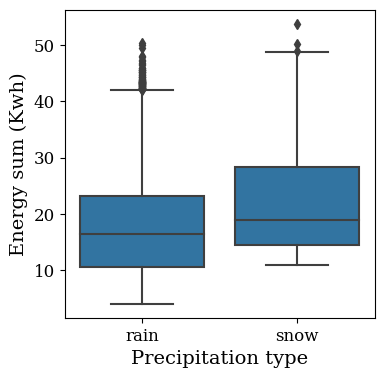

In [ ]:
base_color= sb.color_palette()[0]
plt.figure(figsize = [4,4])
sb.boxplot(x='precipType' , y='energy' ,data=df1 ,color =base_color);

plt.xlabel("Precipitation type" ,fontsize = 14)
plt.ylabel("Energy sum (Kwh)" ,fontsize = 14 )
plt.xticks(fontsize = 12  )
plt.yticks(fontsize = 12)

from google.colab import files
plt.savefig("preciptation vs energy sum.png" ,dpi =300 , bbox_inches='tight')
files.download("preciptation vs energy sum.png")